In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/music_data_raw.csv")

In [4]:
df.describe()

,age,years_of_education,wais3,wais4,waisvocabulary,raven,digit_span,spatial_span,melody_span,nback,...,gold_msi_general_sophistication,bfi_extraversion,bfi_agreeableness,bfi_conscientiousness,bfi_negative_emotionality,bfi_open_mindedness,ses_nuclear_family,AddMusicTraining[years],lastMusicActivity[years],training[years]
count,1438.000000,1438.000000,90.000000,1336.000000,1426.000000,1438.000000,1433.000000,1433.000000,1432.000000,1434.000000,...,1438.000000,1438.000000,1438.000000,1438.000000,1438.000000,1438.000000,1438.000000,213.000000,213.000000,740.000000
mean,22.255216,15.877608,45.877778,40.857036,0.715422,20.178025,10.081647,8.768667,24.532123,16.923989,...,77.844228,40.209318,46.203060,41.636300,36.175939,48.210709,47.447844,1.845070,4.276995,11.883784
std,3.224314,2.200534,6.745498,8.679810,0.149680,5.775577,2.197073,1.908077,6.335817,10.705886,...,25.123842,8.040347,6.566437,8.673494,9.760617,7.465586,15.819981,1.209021,1.405275,4.067097
min,18.000000,11.000000,29.000000,10.000000,0.175439,4.000000,4.000000,1.500000,4.500000,-40.000000,...,21.000000,15.000000,22.000000,12.000000,12.000000,19.000000,8.000000,1.000000,1.000000,1.000000
25%,20.000000,14.000000,41.000000,36.000000,0.631579,16.000000,8.500000,7.500000,20.000000,14.000000,...,56.000000,35.000000,42.000000,36.000000,29.000000,43.000000,37.000000,1.000000,5.000000,10.000000
50%,22.000000,16.000000,45.000000,42.000000,0.719298,20.000000,10.000000,8.500000,24.000000,20.000000,...,79.000000,40.000000,47.000000,42.000000,36.000000,49.000000,52.000000,1.000000,5.000000,12.000000
75%,24.000000,17.000000,51.000000,48.000000,0.824561,25.000000,11.500000,10.000000,29.000000,24.000000,...,101.000000,46.000000,51.000000,48.000000,43.000000,54.000000,60.500000,2.000000,5.000000,14.000000
max,30.000000,25.000000,60.000000,57.000000,1.000000,37.000000,19.500000,27.500000,47.000000,30.000000,...,124.000000,59.000000,60.000000,60.000000,60.000000,60.000000,66.000000,5.000000,5.000000,26.000000


In [5]:
df.isnull().sum()

unit_short                                  0
subject_ID                                  0
sex                                         0
age                                         0
years_of_education                          0
group                                       0
country                                     0
unit                                        0
subject_ID of the matched participant     164
wais3                                    1348
wais4                                     102
waisvocabulary                             12
raven                                       0
digit_span                                  5
spatial_span                                5
melody_span                                 6
nback                                       4
PROMSMELODYSCORE                            0
PROMSTUNINGSCORE                            0
PROMSBEATSCORE                              0
PROMSSPEEDSCORE                             0
PROMSTOTALSCORE                   

## Initial Observations

- The dataset contains 1,438 participants and 49 variables.
- Most demographic, personality, and Gold-MSI variables are complete.
- The primary memory variables (digit_span, spatial_span, and melody_span) contain very few missing values.
- Some cognitive variables, such as WAIS-III, have substantial missingness and may require exclusion from further analysis.
- The n-back variable contains negative values, which should be investigated using the dataset documentation before analysis.

In [6]:
import matplotlib.pyplot as plt

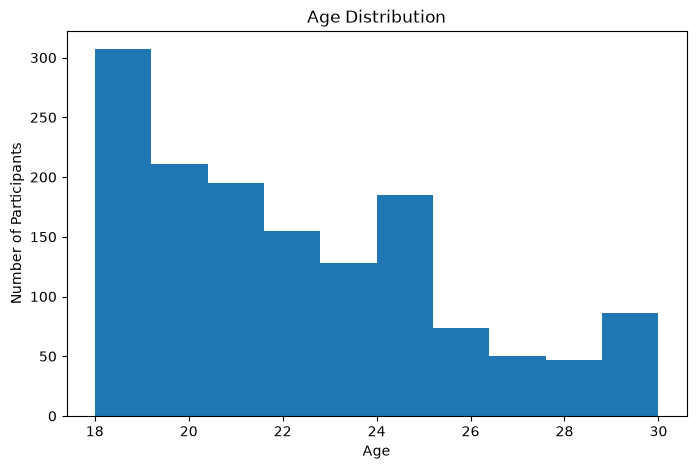

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=10)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Participants")

plt.show()

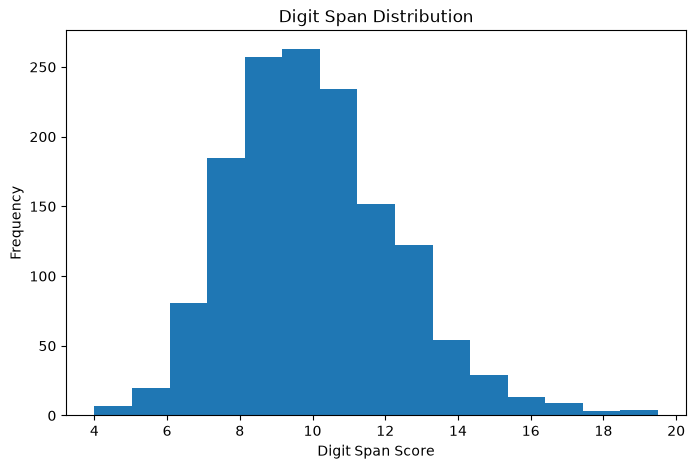

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["digit_span"], bins=15)

plt.title("Digit Span Distribution")

plt.xlabel("Digit Span Score")

plt.ylabel("Frequency")

plt.show()

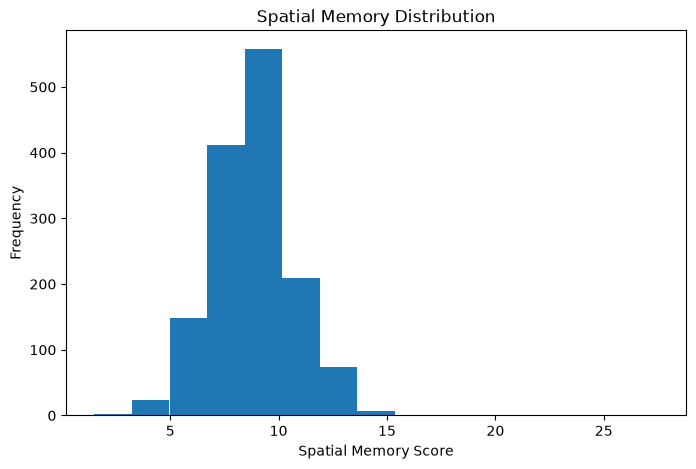

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["spatial_span"], bins=15)
plt.title("Spatial Memory Distribution")
plt.xlabel("Spatial Memory Score")
plt.ylabel("Frequency")
plt.show()


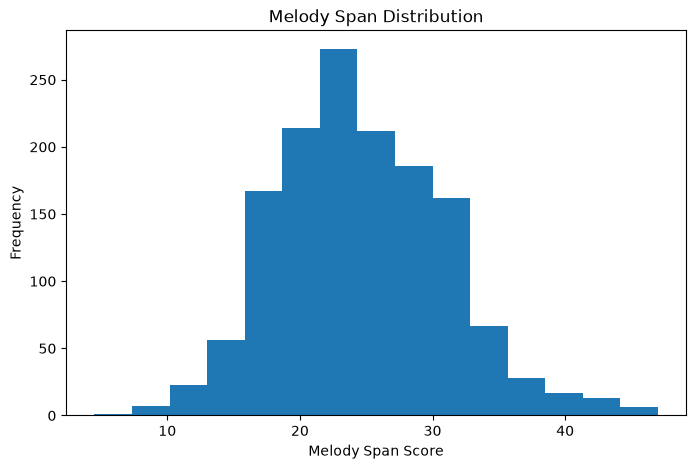

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["melody_span"], bins=15)

plt.title("Melody Span Distribution")

plt.xlabel("Melody Span Score")

plt.ylabel("Frequency")

plt.show()

## Observations

### Age Distribution
- Participant ages range from 18 to 30 years, with the majority concentrated between 18 and 25 years.
- The age distribution is positively (right) skewed, indicating that younger participants are more heavily represented.
- No implausible age values were observed, suggesting good data quality for this variable.
- The sample primarily represents young adults, which should be considered when interpreting the study findings.

### Digit Span Distribution
- Digit Span scores are approximately normally distributed with a slight positive skew.
- Most participants scored between 8 and 12, indicating moderate variability in verbal working memory performance.
- The mean and median are very similar, suggesting a fairly symmetric distribution.
- A small number of participants achieved exceptionally high scores; these appear plausible and are retained for further analysis.

### Spatial Span Distribution
- Spatial Span scores exhibit a unimodal distribution with a slight positive skew.
- Most observations fall between approximately 5 and 12, with relatively few participants achieving higher scores.
- The variable demonstrates reasonable variability without obvious irregularities.
- The unusually high maximum value observed in the summary statistics will be investigated further to determine whether it reflects genuine observations or requires additional verification.

### Melody Span Distribution
- Melody Span scores display an approximately normal distribution with a single prominent peak.
- Most participants scored between 18 and 30, indicating a balanced spread around the mean.
- The distribution shows no obvious anomalies, gaps, or multiple peaks.
- A small number of high-scoring participants are present but appear to represent genuine variation rather than data quality issues.

### Overall Summary
- All three memory measures demonstrate sufficient variability for subsequent statistical analysis and predictive modeling.
- Digit Span and Melody Span are approximately normally distributed, while Spatial Span exhibits a mild positive skew.
- No major data quality concerns were identified from the distributional analysis.
- The dataset appears suitable for investigating the relationship between musical training and memory performance.

In [13]:
memory_df = df[["digit_span", "spatial_span", "melody_span"]]

memory_df.corr()

,digit_span,spatial_span,melody_span
digit_span,1.000000,0.303121,0.337191
spatial_span,0.303121,1.000000,0.204335
melody_span,0.337191,0.204335,1.000000


In [14]:
import seaborn as sns

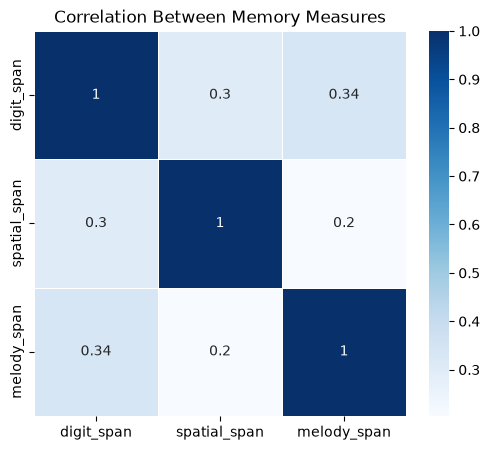

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(
    memory_df.corr(),
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Between Memory Measures")

plt.show()

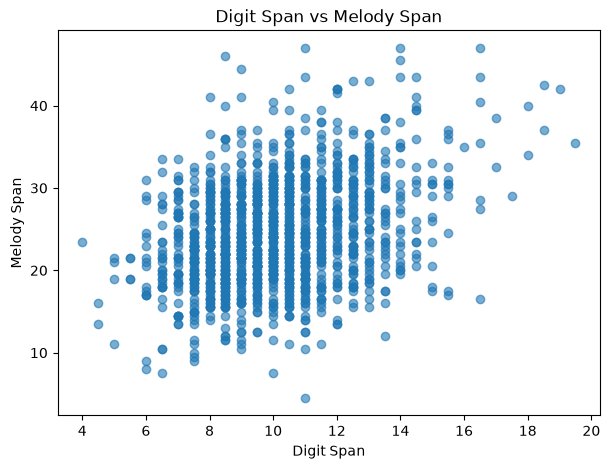

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["digit_span"],
    df["melody_span"],
    alpha=0.6
)

plt.title("Digit Span vs Melody Span")

plt.xlabel("Digit Span")

plt.ylabel("Melody Span")

plt.show()

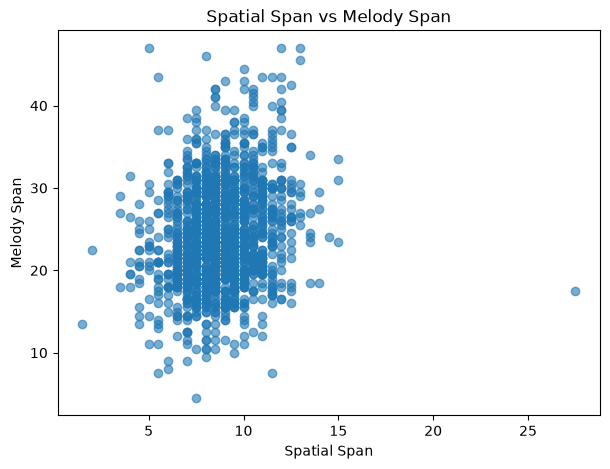

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["spatial_span"],
    df["melody_span"],
    alpha=0.6
)

plt.title("Spatial Span vs Melody Span")

plt.xlabel("Spatial Span")

plt.ylabel("Melody Span")

plt.show()

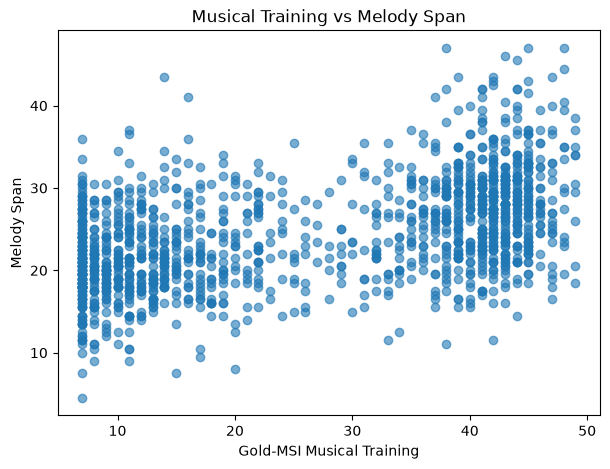

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["gold_msi_musical_training"],
    df["melody_span"],
    alpha=0.6
)

plt.title("Musical Training vs Melody Span")

plt.xlabel("Gold-MSI Musical Training")

plt.ylabel("Melody Span")

plt.show()

In [19]:
selected_columns = [
    "gold_msi_musical_training",
    "gold_msi_general_sophistication",
    "digit_span",
    "spatial_span",
    "melody_span"
]

df[selected_columns].corr()

,gold_msi_musical_training,gold_msi_general_sophistication,digit_span,spatial_span,melody_span
gold_msi_musical_training,1.000000,0.913429,0.093125,0.155358,0.499812
gold_msi_general_sophistication,0.913429,1.000000,0.110783,0.115388,0.482225
digit_span,0.093125,0.110783,1.000000,0.303121,0.337191
spatial_span,0.155358,0.115388,0.303121,1.000000,0.204335
melody_span,0.499812,0.482225,0.337191,0.204335,1.000000


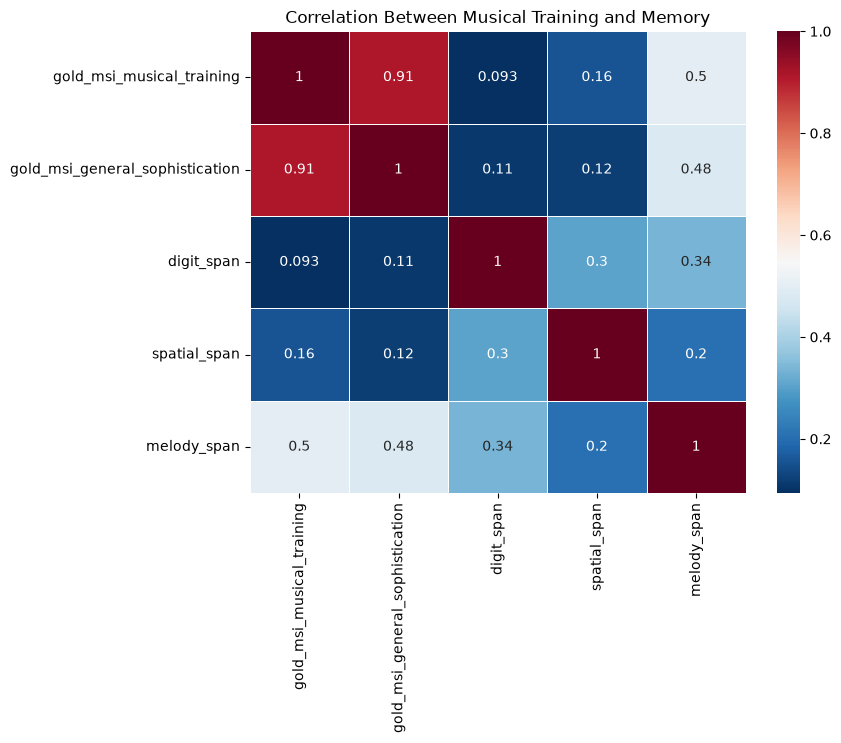

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[selected_columns].corr(),
    annot=True,
    cmap="RdBu_r",
    linewidths=0.5
)

plt.title("Correlation Between Musical Training and Memory")

plt.show()

# Final Findings

## Dataset Overview

- The dataset contains **1,438 participants** and **49 variables**, including demographic information, cognitive assessments, musical training measures, personality traits, and socioeconomic indicators.
- The participant sample primarily consists of **young adults (18–30 years)**, with a mean age of approximately **22.3 years**.
- Most variables are complete, with only a few cognitive measures containing missing values. The primary target variables (Digit Span, Spatial Span, and Melody Span) contain very few missing observations and are suitable for further analysis.

---

## Data Quality Assessment

- No duplicate participant records were identified.
- Most variables exhibit high data completeness.
- Variables such as **WAIS-III**, **AddMusicTraining[years]**, and **LastMusicActivity[years]** contain substantial missing values and will require careful consideration before inclusion in predictive models.
- No obvious data quality issues or implausible values were observed during the initial exploratory analysis.

---

## Distribution of Key Variables

### Age
- The age distribution is positively skewed, with most participants between **18 and 25 years**.
- The dataset primarily represents young adults; therefore, findings should not be generalized beyond this population.

### Memory Measures
- **Digit Span** exhibits an approximately normal distribution with slight positive skewness.
- **Spatial Span** shows a unimodal distribution with mild positive skew and contains one unusually high observation that will be investigated further.
- **Melody Span** displays an approximately normal distribution with good variability across participants.

Overall, all three memory measures demonstrate sufficient variation for statistical analysis and machine learning.

---

## Relationships Between Memory Measures

Positive correlations were observed among all three working memory tasks.

| Variable Pair | Correlation (r) | Interpretation |
|---------------|----------------:|---------------|
| Digit Span ↔ Melody Span | **0.337** | Weak positive |
| Digit Span ↔ Spatial Span | **0.303** | Weak positive |
| Spatial Span ↔ Melody Span | **0.204** | Weak positive |

These findings indicate that while the three assessments measure related aspects of working memory, they also capture distinct cognitive abilities.

---

## Musical Training and Memory Performance

The strongest relationship observed during the exploratory analysis was between **Musical Training** and **Melody Span**.

| Variable Pair | Correlation (r) | Interpretation |
|---------------|----------------:|---------------|
| Gold-MSI Musical Training ↔ Melody Span | **0.500** | Moderate positive |
| Gold-MSI General Sophistication ↔ Melody Span | **0.482** | Moderate positive |
| Gold-MSI Musical Training ↔ Spatial Span | **0.155** | Very weak positive |
| Gold-MSI Musical Training ↔ Digit Span | **0.093** | Very weak positive |

These results suggest that musical training is more strongly associated with **auditory working memory** than with verbal or visuospatial working memory.

---

## Feature Selection Considerations

- **Gold-MSI Musical Training** and **Gold-MSI General Sophistication** are highly correlated (**r = 0.913**), indicating potential multicollinearity.
- These variables will be evaluated carefully during feature engineering to determine whether both should be retained in the predictive models.

---

## Limitations

- The analysis presented in this notebook is exploratory and descriptive.
- Correlation identifies statistical associations but **does not establish causation**.
- The participant sample consists primarily of young adults, limiting the generalizability of the findings.
- Additional statistical testing and predictive modeling are required before drawing substantive conclusions.

---

## Next Steps

The next stage of the project will focus on:

1. Data preprocessing and feature engineering.
2. Handling missing values and preparing variables for modeling.
3. Feature selection and multicollinearity assessment.
4. Building regression models to predict:
   - Digit Span
   - Spatial Span
   - Melody Span
5. Comparing model performance and identifying the variables most strongly associated with working memory performance.